In [38]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict
import json

In [39]:
gen_llm = ChatOllama(model= 'qwen3:0.6b', temperature=0.8)
evl_llm = ChatOllama(model= 'qwen3:8b', temparature=0)

In [40]:
prompt = "write a short birthday wishing message"

In [41]:
response1 = gen_llm.invoke(prompt)
print(response1)

content='Happy Birthday! 🎉 Remember the joy of... [something]? May your day be a special day! 🌟 Love, [Your Name]' additional_kwargs={} response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-09-17T07:24:13.6573273Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9125487900, 'load_duration': 2594376700, 'prompt_eval_count': 16, 'prompt_eval_duration': 87006000, 'eval_count': 257, 'eval_duration': 6439307000, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'} id='lc_run--01a0ae40-4c32-7400-9615-0ff0fd812854-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 257, 'total_tokens': 273}


In [42]:
response2 = evl_llm.invoke(prompt)
print(response2)

content='"Happy Birthday! May your day be filled with joy, your year with happiness, and your heart with gratitude. Here\'s to another year of amazing adventures! 🎉"' additional_kwargs={} response_metadata={'model': 'qwen3:8b', 'created_at': '2026-09-17T07:26:38.4326008Z', 'done': True, 'done_reason': 'stop', 'total_duration': 144659382700, 'load_duration': 18999364400, 'prompt_eval_count': 16, 'prompt_eval_duration': 1040941000, 'eval_count': 356, 'eval_duration': 124485868000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'} id='lc_run--01a0ae40-704a-7b42-b930-d45d8b0f981b-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 356, 'total_tokens': 372}


In [43]:
question = prompt
answer = response1.content
feedback = f"""You are a strict, highly critical QA evaluator. Your job is to thoroughly critique the provided answer and assign an aggressive, accurate score. Do NOT be lenient. 

            CRITERIA FOR SCORING:
            - 9-10: Perfect, comprehensive, fully accurate, and contains zero fluff or ambiguity.
            - 7-8: Accurate and clear, but missing minor depth or could be formatted better.
            - 5-6: Technically correct but vague, incomplete, or partially unclear.
            - 1-4: Incorrect, missing key details, or unhelpful.

            QUESTION:
            {question}

            ANSWER TO EVALUATE:
            {answer}

            INSTRUCTIONS:
            1. First, analyze missing points, inaccuracies, or clarity issues.
            2. Based on your critique, determine the numerical score.
            3. Output ONLY a valid JSON object matching this schema:
            {{"score": <integer from 1 to 10>, "feedback": "<one concise sentence explaining the grade>"}}
            """

response = evl_llm.invoke(feedback)
print(response.content)

{"score": 5, "feedback": "The answer is technically correct but incomplete and vague, containing placeholders that render it unusable as a standalone birthday message."}


In [44]:
json_response = json.loads(response.content)

In [45]:
print(json_response)

{'score': 5, 'feedback': 'The answer is technically correct but incomplete and vague, containing placeholders that render it unusable as a standalone birthday message.'}


In [46]:
print(type(response.content))

<class 'str'>


In [47]:
class State(TypedDict):
    question: str
    answer: str
    score: int
    feedback: str
    iteration: int

In [48]:
def generating_answer(St : State) -> State:
    question = St['question']
    answer = St['answer']
    feedback = St['feedback']
    iteration = St['iteration']

    iteration += 1

    prompt = ''
    if iteration == 1:
        prompt = f'Answer this question clearly:\n{question}'
    else :
        prompt = f"""Improve the following answer to the question based on the feedback.
                Question: {question}
                Current Answer: {answer}
                Feedback: {feedback}

                STRICT OUTPUT RULES:
                - Output ONLY the improved answer text, nothing else.
                - Do NOT mention what you improved or changed, and do NOT add any meta-commentary.
                - Do NOT include headers, labels, or titles like "Improved Answer:".
                - Do NOT give multiple options or variations — provide exactly one answer.
                - Do N
                """
        
    response = gen_llm.invoke(prompt)
    new_answer = response.content

    print(f"Iteration: {iteration}\n")
    if iteration == 1:
        print(f"Generated Answer: {new_answer}\n")
    else :
        print(f"Impoved Answer: {new_answer}\n")

    St['iteration'] = iteration
    St['answer'] = new_answer
    return St

In [49]:
def evaluating_answer(St : State) -> State:
    question = St['question']
    answer = St['answer']

    prompt = feedback = f"""You are a strict, highly critical QA evaluator. Your job is to thoroughly critique the provided answer and assign an aggressive, accurate score. Do NOT be lenient. 

                        CRITERIA FOR SCORING:
                        - 9-10: Perfect, comprehensive, fully accurate, and contains zero fluff or ambiguity.
                        - 7-8: Accurate and clear, but missing minor depth or could be formatted better.
                        - 5-6: Technically correct but vague, incomplete, or partially unclear.
                        - 1-4: Incorrect, missing key details, or unhelpful.

                        QUESTION:
                        {question}

                        ANSWER TO EVALUATE:
                        {answer}

                        INSTRUCTIONS:
                        1. First, analyze missing points, inaccuracies, or clarity issues.
                        2. Based on your critique, determine the numerical score.
                        3. Output ONLY a valid JSON object matching this schema:
                        {{"score": <integer from 1 to 10>, "feedback": "<one concise sentence explaining the grade>"}}
                        """

    response = evl_llm.invoke(prompt)

    try:
        json_response = json.loads(response.content)
        score = int(json_response['score'])
        feedback = json_response['feedback']
    except:
        score = 1
        feedback = 'no feedback found'

    print(f'Score: {score}\n')
    print(f'Feedback: {feedback}\n')
    print('-'*50)
    print()

    St['score'] = score
    St['feedback'] = feedback

    return St  
    
    

In [50]:
def check_quality(St : State) -> State:
    if St['score'] > 7 or St['iteration'] >= 5:
        return "done"
    return "re_evl"

In [51]:
graph = StateGraph(State)

graph.add_node("GEN_ANS", generating_answer)
graph.add_node("EVL_ANS", evaluating_answer)

graph.add_edge(START, 'GEN_ANS')
graph.add_edge('GEN_ANS', 'EVL_ANS')

graph.add_conditional_edges('EVL_ANS', check_quality, {'re_evl': 'GEN_ANS', 'done': END})

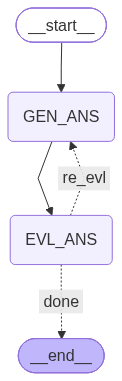

In [52]:
graph.compile()

In [53]:
agent = graph.compile()

In [54]:
intial_state = {
    'question': 'write a short note for a teacher from the students perspective for her farewelle,',
    'iteration': 0,
    'answer': '',
    'feedback': '',
    'score': 0
}
final_state = agent.invoke(intial_state)

Iteration: 1

Generated Answer: **Dear [Teacher's Name],**  

I hope this note finds you well. It’s my honor to say goodbye to [Teacher's Name], and I want to take a moment to express my gratitude for everything you’ve brought to us. Your classroom was a bright, ever-present part of our lives, and I’ll never forget the joy and support you gave us. I’m so grateful to have had the chance to learn and grow with you. I hope you have a great day and that we’ll meet again in the future.  

With love,  
[Your Name]  

---  
This note balances gratitude, warmth, and a touch of personalization, keeping it heartfelt and concise.

Score: 8

Feedback: The note is warm and sincere but lacks specific examples of the teacher's impact, which could enhance its depth and personalization.

--------------------------------------------------



In [55]:
print(final_state)

{'question': 'write a short note for a teacher from the students perspective for her farewelle,', 'answer': "**Dear [Teacher's Name],**  \n\nI hope this note finds you well. It’s my honor to say goodbye to [Teacher's Name], and I want to take a moment to express my gratitude for everything you’ve brought to us. Your classroom was a bright, ever-present part of our lives, and I’ll never forget the joy and support you gave us. I’m so grateful to have had the chance to learn and grow with you. I hope you have a great day and that we’ll meet again in the future.  \n\nWith love,  \n[Your Name]  \n\n---  \nThis note balances gratitude, warmth, and a touch of personalization, keeping it heartfelt and concise.", 'score': 8, 'feedback': "The note is warm and sincere but lacks specific examples of the teacher's impact, which could enhance its depth and personalization.", 'iteration': 1}


In [56]:
print("User: ",final_state['question'])
print()
print("AI Agent: ",final_state['answer'])

User:  write a short note for a teacher from the students perspective for her farewelle,

AI Agent:  **Dear [Teacher's Name],**  

I hope this note finds you well. It’s my honor to say goodbye to [Teacher's Name], and I want to take a moment to express my gratitude for everything you’ve brought to us. Your classroom was a bright, ever-present part of our lives, and I’ll never forget the joy and support you gave us. I’m so grateful to have had the chance to learn and grow with you. I hope you have a great day and that we’ll meet again in the future.  

With love,  
[Your Name]  

---  
This note balances gratitude, warmth, and a touch of personalization, keeping it heartfelt and concise.
